# **Generate the input pickle file from the glacier image for the simulation**
This notebook generates the requiered pickle file for the simulation of the bottom topography of the Tsanfleuron glacier.

### **Input** : 
* path to the training image of the glacier in a tiff format.
* path to the glacier mask in a tiff format.
* path to the GPR point set csv

### **Output** : 
* .pickle binary files to be open with the simulation script

In [8]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import geopandas as gpd
import georasters as gr
import time 
from random import seed
seed(1)
from random import random
import csv


import tkinter as tk
from tkinter import filedialog

## Import the data 
The DEM will be put in the same grid than the simulation grid (mask grid), in order to ease the volume estimation after the simulations. (ON PEUT REMOVE LE DEM)

In [52]:
file_path_ti   = '../data/TI/tif/ti_alti2_2016_2m.tif'
file_path_Mask = '../data/Masks/tif/glacier_mask_2m.tif'
file_path_DEM  = '../data/DEM/tif/DEM_Galcier_adapt.tif'

if os.path.isfile(file_path_ti):
    print('Le fichier est présent. import')
    data_ti = gr.from_file(file_path_ti)
    (xmin, xsize, x, ymax, y, ysize) = data_ti.geot

else:
    print('error')
    
if os.path.isfile(file_path_Mask):
    print('Le fichier est présent. import')
    data_Mask = gr.from_file(file_path_Mask)

else:
    print('error')
    
if os.path.isfile(file_path_DEM):
    print('Le fichier est présent. import')
    data_DEM = gr.from_file(file_path_DEM)

else:
    print('error')
    
    
print('\nInfos')
print('DEM geometry :' + str(data_ti.geot))
print('DEM shape :'+ str(data_ti.shape))

Le fichier est présent. import
Le fichier est présent. import
Le fichier est présent. import

Infos
DEM geometry :(583242.0, 2.0, 0.0, 131224.0, 0.0, -2.0)
DEM shape :(1557, 2967)


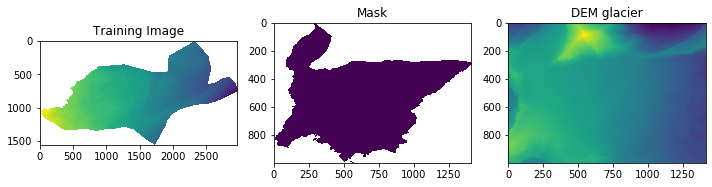

In [55]:
data_ti.raster[data_ti.raster==data_ti.min()]=np.nan

plt.subplots(1,3,figsize=(10,10))
plt.subplot(1,3,1)
plt.imshow(data_ti.raster)
plt.title('Training Image')
plt.subplot(1,3,2)
plt.imshow(data_Mask.raster)
plt.title('Mask')
plt.subplot(1,3,3)
plt.imshow(data_DEM.raster)
plt.title('DEM glacier')
plt.tight_layout()
plt.show()

In [56]:
#Import the point set hard data
path_csv = '../data/PointSet/csv/'
Hard_GPR = pd.read_csv(path_csv+'bedRock_GPR.csv',delimiter =';')
Hard_MNT = pd.read_csv(path_csv+'bedRock_MNT.csv',delimiter='\t')

## We create a new mask/mesh that regroupe the glacier and the ti and clean the hard data set

In [57]:
#Create a mesh grid witht the dimension of the DEM ### c'est pour faire quoi?
x_v = np.array(range(data_ti.shape[1]))*data_ti.geot[1] + data_ti.geot[0]
y_v = np.array(range(data_ti.shape[0]))*data_ti.geot[5] + data_ti.geot[3]
X_dem, Y_dem = np.meshgrid(x_v,y_v)

In [58]:
#Clean the point Set data to the geometry of the mask  ### c'est bien ça, tu clean les hard data?
Hard_pts = Hard_MNT.append(Hard_GPR[['X','Y','Bed_Alt']])
borders  = [X_dem.min(),X_dem.max(),Y_dem.min(),Y_dem.max(), Hard_pts['X'].min(), Hard_pts['X'].max(),Hard_pts['Y'].min(), Hard_pts['Y'].max()]

x_min = min(borders[0],borders[4])
x_max = max(borders[1],borders[5])
y_min = min(borders[2],borders[6])
y_max = max(borders[3],borders[7])

nx = np.int(np.ceil((x_max - x_min)/2))
ny = np.int(np.ceil((y_max - y_min)/2))
referential = [x_min, y_max]

#Add to the data frame the cell_x and cell_y coordinate
Hard_pts.insert(0,'cell_x',np.around((Hard_pts['X']-referential[0])/data_ti.geot[1],decimals=0))
Hard_pts.insert(1,'cell_y',np.around((Hard_pts['Y']-referential[1])/data_ti.geot[5],decimals=0))

#Remove the points that share the same cell_x and cell_y
Hard_pts = Hard_pts.drop_duplicates(subset = ['cell_x','cell_y'] )
Hard_pts.rename(columns={'Bed_Alt':'alt'}, inplace=True)


## We create the new masks

In [59]:
#empty masks
ti_bedRock   = np.full((ny+1,nx+1),np.nan)
mask_bedRock = np.zeros((ny+1,nx+1))
dem_glacier  = np.full((ny+1,nx+1),np.nan)
mask_glacier = np.zeros((ny+1,nx+1))
mask_simu    = np.zeros((ny+1,nx+1))

In [60]:
#position of the old grids in the new grid
referential_ti   = np.round([data_ti.geot[0]-referential[0], data_ti.geot[3]-referential[1]])/2
referential_mask = np.round([(data_Mask.geot[0]-referential[0])/data_Mask.geot[1], (data_Mask.geot[3]-referential[1])/data_Mask.geot[5]])

In [65]:
#merge the olds and new grids
ti_bedRock[int(referential_ti[1]):int(referential_ti[1]+data_ti.shape[0]) , int(referential_ti[0]):int(referential_ti[0]+data_ti.shape[1])] = data_ti.raster
mask_bedRock[ti_bedRock>0] = 1
mask_glacier[int(referential_mask[1]):int(referential_mask[1]+data_Mask.shape[0]) , int(referential_mask[0]):int(referential_mask[0]+data_Mask.shape[1])] = data_Mask.raster
dem_glacier[int(referential_mask[1]):int(referential_mask[1]+data_Mask.shape[0]) , int(referential_mask[0]):int(referential_mask[0]+data_Mask.shape[1])] = data_DEM.raster
dem_glacier[mask_glacier!=1] = np.nan
mask_simu[ti_bedRock>1] = 1
mask_simu[mask_glacier>=1] = 1

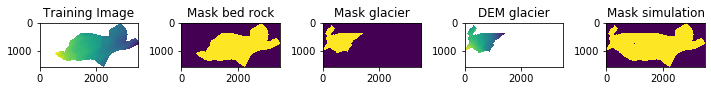

In [66]:
plt.subplots(1,5,figsize=(10,10))
plt.subplot(1,5,1)
plt.imshow(ti_bedRock)
plt.title('Training Image')
plt.subplot(1,5,2)
plt.imshow(mask_bedRock)
plt.title('Mask bed rock')
plt.subplot(1,5,3)
plt.imshow(mask_glacier)
plt.title('Mask glacier')
plt.subplot(1,5,4)
plt.imshow(dem_glacier)
plt.title('DEM glacier')
plt.subplot(1,5,5)
plt.imshow(mask_simu)
plt.title('Mask simulation')
plt.tight_layout()
plt.show()

In [18]:
#Note that the mask bed rock is not exported and not used

## We export the data for the simulations

In [19]:
#Clear and create the empty directory for the pickle file
save_path   = '../real_data'

if not(os.path.exists(save_path)):
    os.mkdir(save_path)
else:
    for root, dirs, files in os.walk(save_path, topdown=False):
        for name in files:
            os.remove(os.path.join(root, name))
        for name in dirs:
            os.rmdir(os.path.join(root, name))
        
    os.rmdir(save_path)
    os.mkdir(save_path)

In [21]:
#Save the data
#The data are : [true Mnt, position of the mask, hard_data, ti, [mask_glacier, mask_glacier+ti]
with open(save_path + '/' + 'tsanfleuron_data' + '.pickle', 'wb') as f:  # Python 3: open(..., 'wb')
    pickle.dump([None, [0,nx+1,0,ny+1], Hard_pts,ti_bedRock,[mask_glacier,mask_simu],referential], f, pickle.HIGHEST_PROTOCOL)

## We also export the cut DEM of the glacier, that will be used for the volume estimation

In [67]:
path_dem_cut = '../data/DEM/pickle/DEM_glacier_cut.pickle'
with open(path_dem_cut,'wb')as f:
    pickle.dump(dem_glacier, f, pickle.HIGHEST_PROTOCOL )